<a href="https://colab.research.google.com/github/DebbieJara/novaretail-correlation-analysis/blob/main/NovaRetail_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [4]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar Dataset

In [5]:
# Cargar el dataset y explorar datos
df = pd.read_csv('novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [6]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `satisfaccion` está almacenada como `float64`, sin embargo representa una escala discreta de 1 a 5. Esto requiere conversión a `int` para eliminar decimales. Mantenerla como float podría distorsionar las interpretaciones estadísticas que se obtengan.



**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.


In [7]:
# Corregir el tipo de dato
df['satisfaccion'] = df['satisfaccion'].astype(int)

In [8]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  int64  
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [9]:
# Estadísticas descriptivas de variables numéricas
df.select_dtypes('number').drop(['miembro_premium','abandono'], axis=1).describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.160067,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.753978,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


#### Diagnóstico inicial de variables numéricas

- `edad` — la media y la mediana son muy similares, lo que sugiere una distribución simétrica y sin valores extremos
- `nivel_ingreso` - el máximo de 74,790 es aproximadamente el doble del 75%, lo que indica un posible sesgo a la derecha que vale la pena explorar
- `visitas_mes` - el salto entre el 75% (12 visitas) y el máximo (25 visitas) es notable en comparación con los rangos anteriores, lo que sugiere la presencia de outliers en el extremo superior
- `compras_mes` - la mediana de 1 indica que al menos la mitad de los clientes realiza una compra o menos por mes, revelando un segmento considerable de baja actividad
- `gasto_publicidad_dirigida` - el mínimo de 0 llama la atención ya que podría representar clientes que no recibieron publicidad dirigida o valores no registrados correctamente; merece revisión en etapas posteriores del análisis
- `satisfaccion`- la media y la mediana se ubican alrededor de 3, lo que sugiere una satisfacción moderada con una distribución relativamente simétrica
- `ingreso_anual` - al menos 25% de los clientes registra un ingreso anual de 0, lo cual es un hallazgo relevante dado que esta es la variable objetivo del análisis

#### Explorar variables binarias

In [10]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[['miembro_premium','abandono']].nunique()

,0
miembro_premium,2
abandono,2


#### Diagnóstico inicial de variables binarias

- `miembro_premium` — presenta exactamente 2 valores únicos, lo que confirma que la codificación binaria 0/1 es consistente y no contiene valores inesperados
- `abandono` — registra únicamente 2 valores únicos, validando que su codificación binaria 0/1 es íntegra y no presenta inconsistencias

#### Explorar variables categóricas

In [11]:
# Verificar el número de valores únicos por variable categórica

df.select_dtypes('object').nunique()

,0
id_cliente,15000
tipo_dispositivo,3
region,4


In [12]:
# Explorar variables categóricas y cómo se distribuyen
df.select_dtypes('object').drop(['id_cliente'], axis=1).value_counts()

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
Name: count, dtype: int64

#### Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — El dispositivo móvil concentra la mayor cantidad de usuarios, siendo el canal predominante frente a escritorio y tablet
- `region` - Se observa que la región norte concentra la más usuarios, con una diferencia de 1,326 clientes respecto a la región este, que es la menos representada



## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

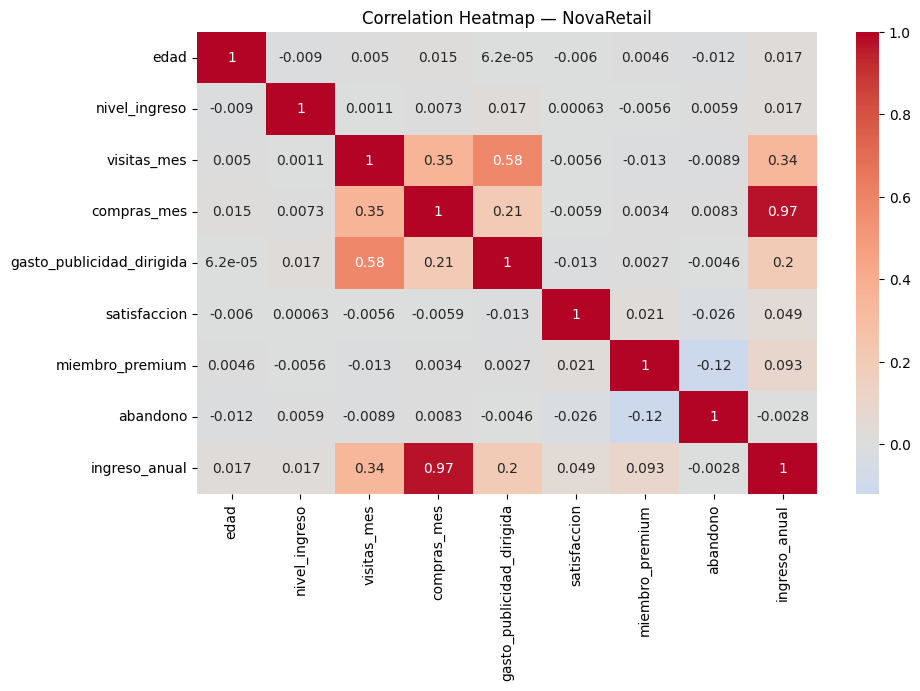

In [13]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.select_dtypes('number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — NovaRetail")
plt.show()

#### Observaciones generales (Heatmap)  
- Se observan 3 hallazogs importantes a resaltar en el heatmap.
    - `visitas_mes` y `gasto_publicidad_dirigida` presentan la correlación positiva más fuerte del heatmap (0.58), sugiriendo que a mayor inversión publicitaria dirigida, mayor actividad del usuario en la plataforma.
    - `visitas_mes` y `compras_mes` muestran una relación positiva moderada (0.35).
    - `miembro_premium` y `abandono` presentan una correlación negativa (-0.12), lo que indica que los clientes con suscripción premium tienden a abandonar menos la plataforma.


#### Observaciones respecto a `ingreso_anual`  
- La correlación respecto a `ingreso anual` y `compras_mes` es de 0.97, siendo la correlación positiva más fuerte, sugiriendo que a más compras realizadas, mayor ingreso a la empresa. Sin embargo, la alta correlación podría explicarse por una dependencia matemática entre ambas variables, lo que amerita verificar si `ingreso_anual` se deriva  directamente `compras_mes`.
- Descartando esa relación, `visitas_mes` es el factor más asociado con `ingreso anual` (0.34).
- `edad`, `nivel_ingreso` y `satisfaccion` muestran correlaciones cercanas a 0, lo que sugiere que no son factores relevantes para explicar el ingreso anual generado.


### Scatterplot general

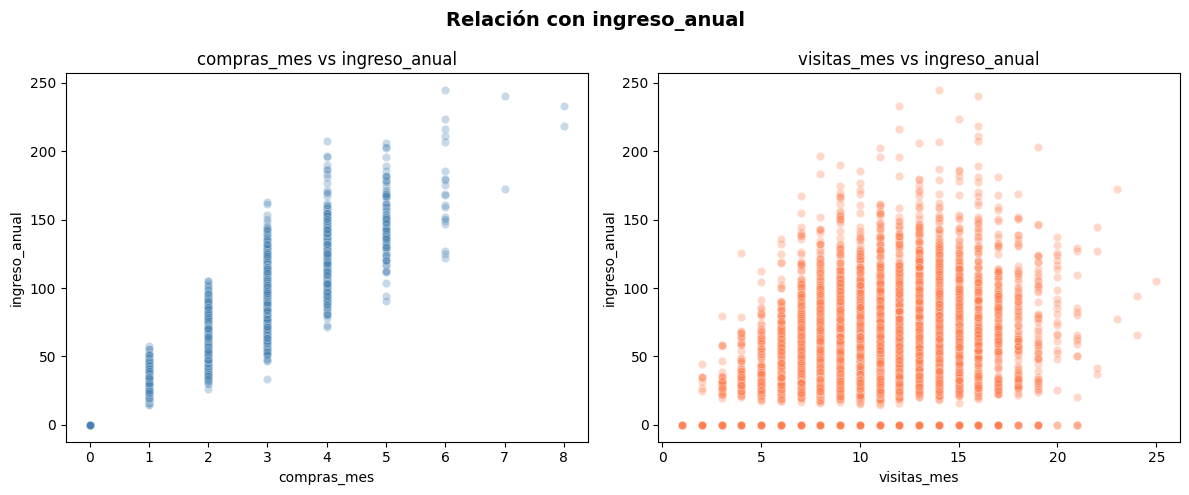

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual',
    alpha=0.3,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('compras_mes vs ingreso_anual')

sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='ingreso_anual',
    alpha=0.3,
    color='coral',
    ax=axes[1]
)
axes[1].set_title('visitas_mes vs ingreso_anual')

plt.suptitle('Relación con ingreso_anual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Con base en el heatmap, se decidió incluir scatterplots para los dos pares con correlación más relevante respecto a `ingreso_anual`,  que es la variable objetivo del análisis. Los demás pares mostraron correlaciones cercanas a 0 y no aportan evidencia visual relevante para responder la pregunta de negocio.

**`compras_mes` vs `ingreso_anual`** —  correlación de 0.97 con `ingreso_anual`, la más alta del dataset. El scatterplot muestra una tendencia lineal clara y ascendente, por lo que se recomienda Pearson para un análisis más profundo.

**`visitas_mes` vs `ingreso_anual`** — segundo factor más asociado con el ingreso anual (0.34). El scatterplot presenta alta dispersión sin una tendencia lineal definida, por lo que se recomienda Spearman para su análisis.

### Scatterplot para pares clave

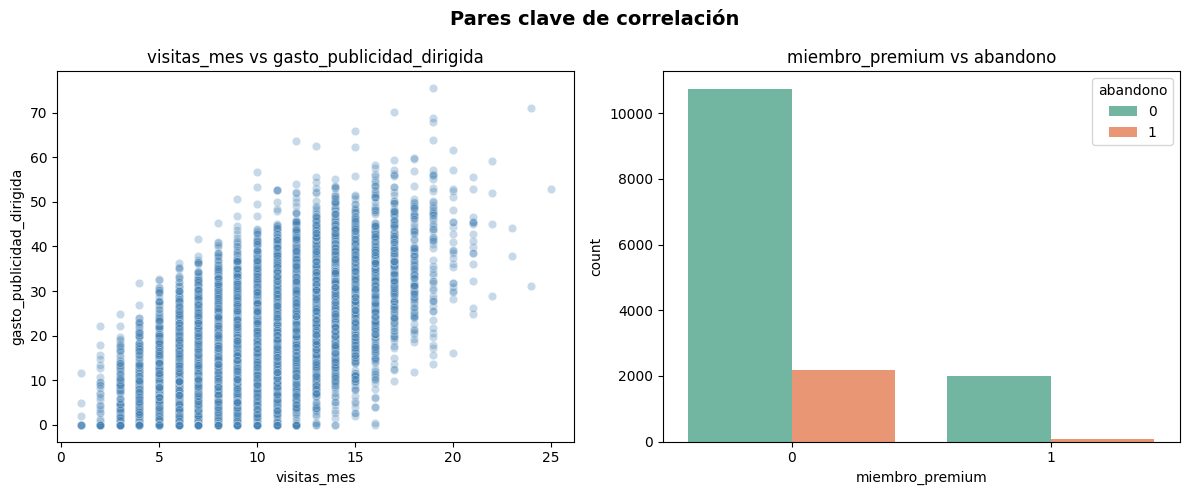

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='gasto_publicidad_dirigida',
    alpha=0.3,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('visitas_mes vs gasto_publicidad_dirigida')

sns.countplot(
    data=df,
    x='miembro_premium',
    hue='abandono',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('miembro_premium vs abandono')

plt.suptitle('Pares clave de correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1094/1351081384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='miembro_premium', y='ingreso_anual', palette='Set2', ax=ax)


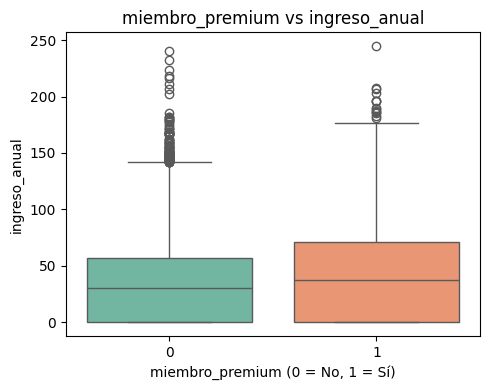

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(data=df, x='miembro_premium', y='ingreso_anual', palette='Set2', ax=ax)
ax.set_title('miembro_premium vs ingreso_anual')
ax.set_xlabel('miembro_premium (0 = No, 1 = Sí)')
ax.set_ylabel('ingreso_anual')

plt.tight_layout()
plt.show()

#### Observaciones iniciales (Scatterplot)

**`visitas_mes` vs `gasto_publicidad_dirigida`**
- Dirección positiva: el scatterplot muestra que a mayor número de visitas mensuales, mayor gasto en publicidad dirigida asignado al usuario
- Dispersión moderada: se observa una forma definida consistente con la correlación de 0.58 observada en el heatmap
- Outliers: se identifican valores extremos en la parte superior del gráfico que podrían influir en el coeficiente de correlación, por lo que se recomienda utilizar el método Spearman para un análisis más robusto

**`miembro_premium` vs `abandono`**
- Dirección: negativa (-0.12) que muestra que los clientes con suscripción premium presentan una menor proporción de abandono respecto a los clientes no premium.
- Nota metodológica: dado que ambas variables son binarias, el scatterplot no es el gráfico más adecuado para este par. Se utilizó un countplot para visualizar la distribución de las combinaciones, lo que confirma la dirección negativa observada en el heatmap.

**`miembro_premium` vs `ingreso_anual`**
- Dirección positiva: los clientes premium (1) muestran una mediana de ingreso anual más alta que los no premium (0)
- Dispersión: mayor en el grupo premium, lo que indica más variabilidad en el ingreso anual de ese segmento
- Outliers: se identifican valores extremos en ambos grupos, más pronunciados en el grupo no premium
- Nota metodológica: dado que `miembro_premium` es una variable binaria, se utilizó un boxplot para comparar la distribución del ingreso anual entre ambos grupos de forma más informativa.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [17]:
# Correlación entre compras_mes e ingreso_anual
corr_pearson  = df['compras_mes'].corr(df['ingreso_anual'], method='pearson')
corr_spearman = df['compras_mes'].corr(df['ingreso_anual'], method='spearman')

print(f"Correlación entre compras_mes e ingreso_anual")
print(f"Pearson: {corr_pearson:.3f}")
print(f"Spearman: {corr_spearman:.3f}")

Correlación entre compras_mes e ingreso_anual
Pearson: 0.967
Spearman: 0.967


In [18]:
# Correlación entre visitas_mes e ingreso_anual
corr_pearson  = df['visitas_mes'].corr(df['ingreso_anual'], method='pearson')
corr_spearman = df['visitas_mes'].corr(df['ingreso_anual'], method='spearman')

print(f"Correlación entre visitas_mes e ingreso_anual")
print(f"Pearson: {corr_pearson:.3f}")
print(f"Spearman: {corr_spearman:.3f}")

Correlación entre visitas_mes e ingreso_anual
Pearson: 0.337
Spearman: 0.321


#### Observaciones de correlación

**compras_mes vs ingreso_anual**
- Correlación: Pearson y Spearman confirman una correlación positiva estable y robusta (0.967), consistente con lo observado en el scatterplot a pesar de la presencia de outliers
- Magnitud: muy alta en ambos métodos, lo que indica una relación fuerte entre las variables
- Colinealidad: la correlación de 0.967 sugiere un posible riesgo de colinealidad, ya que ambas variables podrían estar midiendo el mismo fenómeno
  
**visitas_mes vs ingreso_anual**
- Correlación: Pearson (0.337) y Spearman (0.321) muestran una correlación positiva moderada y estable, indicando que los outliers no generan ningún impacto significativo
- Magnitud: moderada-baja, sugiriendo una relación real pero no determinante
- Colinealidad: no se observa riesgo de colinealidad, ya que ambas variables son suficientemente independientes

### Punto-biserial

In [19]:
# Calcular correlación entre variables relevantes
from scipy import stats

# miembro_premium vs ingreso_anual

corr_pb1, pval1 = stats.pointbiserialr(df['miembro_premium'], df['ingreso_anual'])
print(f"miembro_premium vs ingreso_anual")
print(f"Correlación punto biserial: {corr_pb1:.3f}")
print(f"p-value: {pval1:.3f}")

print()

# abandono vs ingreso_anual
corr_pb2, pval2 = stats.pointbiserialr(df['abandono'], df['ingreso_anual'])
print(f"abandono vs ingreso_anual")
print(f"Correlación punto biserial: {corr_pb2:.3f}")
print(f"p-value: {pval2:.3f}")

miembro_premium vs ingreso_anual
Correlación punto biserial: 0.093
p-value: 0.000

abandono vs ingreso_anual
Correlación punto biserial: -0.003
p-value: 0.729


#### Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación: positiva y con magnitud baja (0.093)
- P-value: la correlación encontrada es confiable, no es casualidad ya que 0.000 indica que la correlación es estadísticamente significativa

**abandono vs ingreso_anual**
- Relación: negativa y con magnitud prácticamente nula (-0.003)
- P-value: la correlación no es estadísticamente significativa; no hay evidencia de que abandono esté asociado con ingreso_anual

### V de Cramér

In [20]:
# Función para calcular V de Cramér
import numpy as np
from scipy.stats import chi2_contingency

def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    return v

In [21]:
# Aplicar V de Cramér en variables relevantes
coef_cramer = cramer_v(df, "region", "tipo_dispositivo")

print("\nCorrelación entre: region y tipo dispositivo")
print(f"V de Cramér: {coef_cramer :.3f}")



Correlación entre: region y tipo dispositivo
V de Cramér: 0.012


#### Observaciones V de Cramér
La correlación entre region vs tipo_dispositivo arroja un valor de 0.012 indicando una asociación prácticamente nula, lo que sugiere que el tipo de dispositivo que usa un cliente no depende de su región geográfica


## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 — `compras_mes` vs `ingreso_anual`

**Evidencia visual:**
El scatterplot muestra una tendencia lineal clara y ascendente entre ambas variables

**Evidencia numérica:**
Pearson y Spearman confirman una correlación positiva estable y robusta (0.967)

**Interpretación**  
Los clientes que realizan más compras al mes tienden a generar mayor ingreso anual para la plataforma

**No podemos afirmar**  
No se puede afirmar que las compras causan el aumento en ingreso anual, solo que las variables están correlacionadas

**Implicación de negocio**  
Se sugiere invertir en estrategias que incentiven la frecuencia de compra, como ofertas por tiempo limitado

### Hallazgo 2 — `miembro_premium` vs `ingreso_anual`

**Evidencia visual:**   
El boxplot muestra que los clientes premium presentan una mediana de ingreso anual más alta que los no premium, con mayor dispersión en ese grupo

**Evidencia numérica:**
El coeficiente de punto biserial es 0.093 con p-value de 0.000, confirmando una correlación positiva baja pero estadísticamente significativa

**Interpretación**  
Los clientes con una suscripción premium tienden a generar mayor ingreso anual para la plataforma, aunque con mayor variabilidad entre ellos

**No podemos afirmar**  
No se puede afirmar que la suscripción premium cause mayor ingreso, solo que ambas variables están positivamente asociadas

**Implicación de negocio**  
Se sugiere invertir en estrategias de retención dirigidas al segmento premium, como programas de lealtad, para mantener y expandir este grupo de alto valor

## Sección 6 - Limitaciones y próximos pasos

#### **Limitaciones**
- Correlación ≠ causalidad
- Se desconoce si `ingreso_anual` se calcula directamente a partir de `compras_mes`, lo que podría explicar la alta correlación entre ambas variables.
- Se desconoce si los datos analizados representan una muestra o el total de clientes de la plataforma, lo que podría afectar la representatividad de los resultados.

#### **Próximos pasos**

**Paso 1: Probar segmentación adicional**
- Opción 1: analizar si el ingreso anual varía según `region`
- Opción 2: analizar si el ingreso anual varía según `tipo_dispositivo`

**Paso 2: Profundizar en `gasto_publicidad_dirigida`**
- Opción 1: Explorar la relación directa entre `gasto_publicidad_dirigida` e `ingreso anual`, dado que mostró una correlación de 0.2 que no fue analizada en profundidad

**Paso 3: Caracterizar el segmento premium**
- Opción 1: Analizar las características comunes de los clientes premium (edad, región, dispositivo, visitas) para identificar patrones que permitan expandir ese segmento